In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import matplotlib.dates as mdates

In [2]:
sys.path.append("../src")
from anomalies import TemporalAnomalyDetector


In [3]:
# Configuración de Rutas
BASE_DIR = Path.cwd().parent
CSV_CHATS = BASE_DIR / "data" / "processed" / "chats_completos.csv"

# Cargamos el Golden Dataset de la Fase 1
df_chats = pd.read_csv(CSV_CHATS)

In [4]:
# Fijamos un 3% de anomalías esperadas
detector = TemporalAnomalyDetector(contamination=0.03) 
df_prepared = detector.prepare_features(df_chats)

# USAMOS LAS VARIABLES LOGARÍTMICAS PARA EVITAR EL SESGO DE LOS SALTOS TEMPORALES
features_to_model = ['Hour', 'Length_Log', 'Time_Delta_Log']

# Ejecución del Modelo Predictivo
df_anomalies = detector.fit_predict(df_prepared, features_to_model)

Realizando Feature Engineering temporal avanzado...
Entrenando Isolation Forest sobre 797 eventos...


In [5]:
# 3. Métricas Básicas
anomalos = df_anomalies[df_anomalies['Is_Anomaly'] == -1]
normales = df_anomalies[df_anomalies['Is_Anomaly'] == 1]

print(f"\n--- Resumen del Isolation Forest ---")
print(f"Total de eventos evaluados: {len(df_anomalies)}")
print(f"Comportamientos Normales: {len(normales)}")
print(f"Anomalías Detectadas (Crisis/Atípicos): {len(anomalos)}")


--- Resumen del Isolation Forest ---
Total de eventos evaluados: 797
Comportamientos Normales: 773
Anomalías Detectadas (Crisis/Atípicos): 24


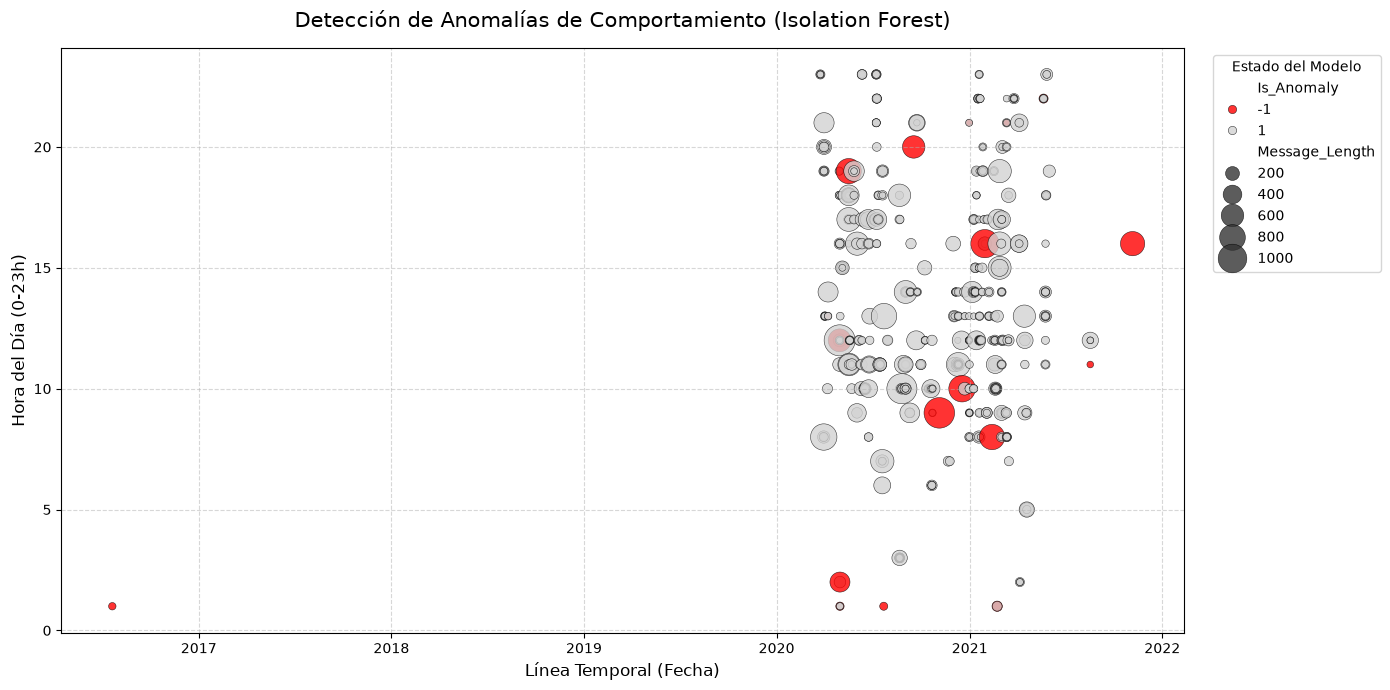

In [6]:
# 4. Visualización Forense (El Gráfico para la Defensa)
plt.figure(figsize=(14, 7))

# Gráfico de dispersión: Timeline vs Hora del Día
sns.scatterplot(
    data=df_anomalies, 
    x='Datetime', 
    y='Hour', 
    hue='Is_Anomaly', 
    palette={1: 'lightgrey', -1: 'red'}, # Rojos para las alertas
    size='Message_Length', # Burbujas grandes = mensajes muy largos (Testamentos)
    sizes=(20, 500),
    alpha=0.8,
    edgecolor='black'
)

plt.title('Detección de Anomalías de Comportamiento (Isolation Forest)', fontsize=15, pad=15)
plt.xlabel('Línea Temporal (Fecha)', fontsize=12)
plt.ylabel('Hora del Día (0-23h)', fontsize=12)

# Ajuste de la leyenda para que no manche los datos
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Estado del Modelo")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [7]:
# 5. Volcado Analítico del Top 10 Anomalías
columnas_mostrar = ['Datetime', 'Emisor', 'Hour', 'Message_Length', 'Time_Delta_Sec', 'Anomaly_Score', 'Mensaje']
top_anomalias = anomalos.sort_values(by='Anomaly_Score').head(10)

print("\n--- TOP 10 EVENTOS MÁS ANÓMALOS MATEMÁTICAMENTE (Mayor a Menor rareza) ---")
display(top_anomalias[columnas_mostrar])


--- TOP 10 EVENTOS MÁS ANÓMALOS MATEMÁTICAMENTE (Mayor a Menor rareza) ---


,Datetime,Emisor,Hour,Message_Length,Time_Delta_Sec,Anomaly_Score,Mensaje
408,2020-11-04 09:15:19,ROBERTO ROSELLI,9,1149,1119296.0,-0.055674,“Acabo de hablar con el tipo de la SEPI. Estáb...
600,2021-01-29 16:35:15,JULIO MARTINEZ SOLA,16,971,0.0,-0.048667,Parece que bien en el sentido de que se le dev...
1,2020-03-23 23:06:48,Miguel Palomero,23,36,115938777.0,-0.047275,Que vais a hacer con la línea aérea?
653,2021-02-22 01:03:59,RODOLFO REYES,1,34,225691.0,-0.035146,Alguna noticia de Antonio Caldeiro
0,2016-07-21 01:53:51,Ramón GORDILS,1,23,0.0,-0.034051,Moncho Gordils por aqui
796,2021-11-05 16:04:54,JULIO MARTÍNEZ SOLA,16,705,6923797.0,-0.032574,Me acaba de llamar a José Ángel Partearroyo de...
101,2020-04-30 02:03:41,RAMÓN GORDILS,2,466,72.0,-0.032241,Tranquilo... Ya nos enteraremos *** En el inte...
284,2020-07-22 01:07:16,DESCONOCIDO,1,36,193788.0,-0.031850,Si bro. Nuestro pana zapatero detrás
291,2020-08-21 03:07:09,ROBERTO ROSELLI,3,5,31341.0,-0.031404,Mamao
656,2021-02-22 01:04:25,RODOLFO REYES,1,8,6.0,-0.030489,Si porfa


In [8]:
CSV_TOP_CHATS = BASE_DIR / "data" / "processed" / "chats_top.csv"
top_anomalias[columnas_mostrar].to_csv(CSV_TOP_CHATS)

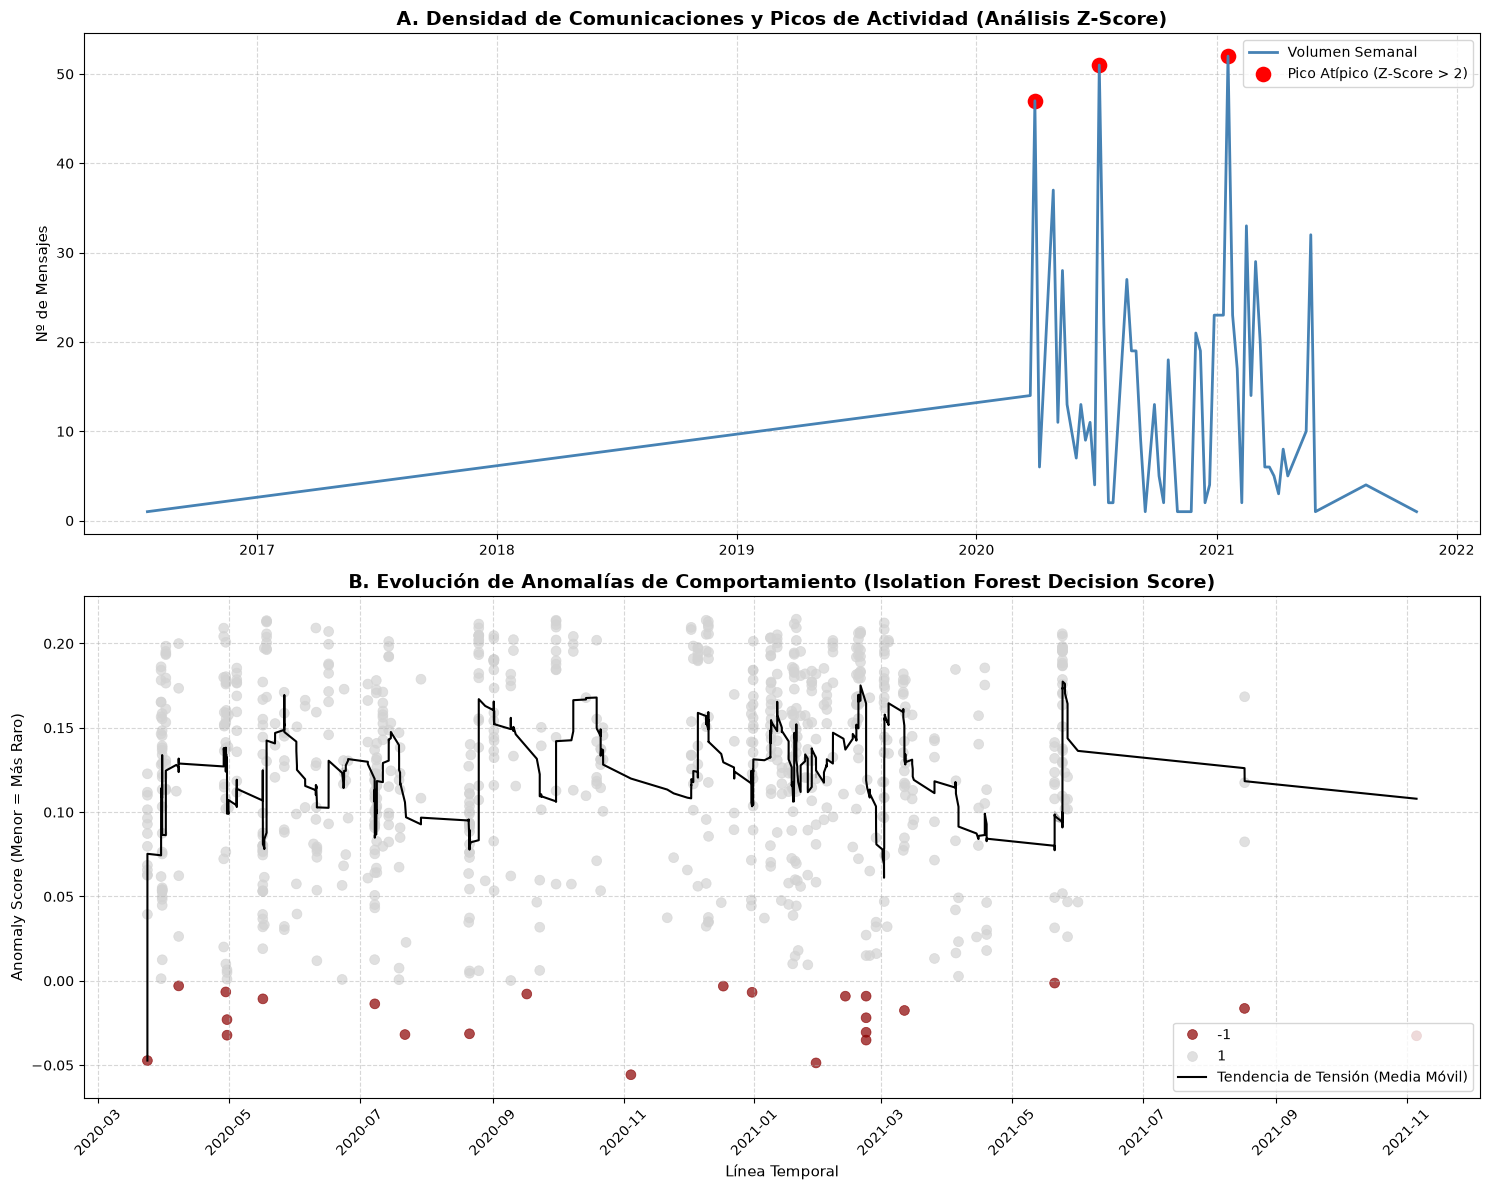

In [12]:
# Agrupamos los mensajes por semana para ver el volumen general (Densidad)
df_anomalies['Week'] = df_anomalies['Datetime'].dt.isocalendar().week
df_anomalies['Year'] = df_anomalies['Datetime'].dt.year
df_weekly = df_anomalies.groupby(['Year', 'Week']).size().reset_index(name='Message_Count')
# Creamos una fecha ficticia para el plot usando el inicio de la semana
df_weekly['Date'] = pd.to_datetime(df_weekly['Year'].astype(str) + df_weekly['Week'].astype(str) + '1', format='%G%V%u')

# Calculamos el Z-Score del volumen semanal para detectar semanas atípicas
df_weekly['Volume_ZScore'] = (df_weekly['Message_Count'] - df_weekly['Message_Count'].mean()) / df_weekly['Message_Count'].std()

# 2. CONFIGURACIÓN DEL PANEL VISUAL (2 Gráficos)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=False)

# --- GRÁFICO A: Densidad de Eventos y Semanas Críticas (Z-Score) ---
# Mostramos el volumen de mensajes a lo largo del tiempo
sns.lineplot(data=df_weekly, x='Date', y='Message_Count', ax=ax1, color='steelblue', linewidth=2, label='Volumen Semanal')
sns.scatterplot(data=df_weekly[df_weekly['Volume_ZScore'] > 2], x='Date', y='Message_Count', ax=ax1, color='red', s=150, label='Pico Atípico (Z-Score > 2)')

ax1.set_title('A. Densidad de Comunicaciones y Picos de Actividad (Análisis Z-Score)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Nº de Mensajes', fontsize=11)
ax1.set_xlabel('')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# --- GRÁFICO B: Profundidad de las Anomalías (Isolation Forest Score) ---
# Excluimos el año 2016 para que la gráfica de 2020-2021 se vea con claridad
df_recent = df_anomalies[df_anomalies['Datetime'].dt.year >= 2020].copy()

# Plot del Anomaly Score. Valores más bajos = Más anómalo
sns.scatterplot(data=df_recent, x='Datetime', y='Anomaly_Score', hue='Is_Anomaly', 
                palette={1: 'lightgrey', -1: 'darkred'}, s=50, alpha=0.7, ax=ax2, edgecolor=None)

# Línea de tendencia (Media móvil) para ver cómo el "nerviosismo" general fluctúa
df_recent = df_recent.sort_values('Datetime')
df_recent['Rolling_Score'] = df_recent['Anomaly_Score'].rolling(window=20, min_periods=1).mean()
sns.lineplot(data=df_recent, x='Datetime', y='Rolling_Score', ax=ax2, color='black', linewidth=1.5, label='Tendencia de Tensión (Media Móvil)')

ax2.set_title('B. Evolución de Anomalías de Comportamiento (Isolation Forest Decision Score)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Anomaly Score (Menor = Más Raro)', fontsize=11)
ax2.set_xlabel('Línea Temporal', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='lower right')

# Formateo de fechas en el eje X para que sea legible
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()